## Try some bond dissociations of PFAS molecules

## Fluoromethane 

Find the dissociation curve with FCI and DFT

In [12]:
import pandas as pd
import numpy as np
from nbed.utils import pubchem_mol_geometry, build_ordered_xyz_string, save_ordered_xyz_file

def init_mol_df(mol_name: str, f_index: int = None, c_index: int = None) -> pd.DataFrame:
    mol_geometry = pubchem_mol_geometry(mol_name)
    print(mol_geometry)

    if f_index is None or c_index is None:
        f_index = input("Enter the index of the fluorine atom: ")
        f_index = int(f_index)
        c_index = input("Enter the index of the carbon atom: ")
        c_index = int(c_index)

    start_f = np.array(mol_geometry[f_index][1])
    start_c = np.array(mol_geometry[c_index][1])
    displacement = start_f - start_c

    positions = [start_c + i *displacement for i in np.linspace(0.5,2.5,25)]
    distances = [np.linalg.norm(i) for i in positions]
    df = pd.DataFrame(index = range(len(distances)), columns = ["distances", "positions", "xyz"])
    df["distances"] = distances
    df["positions"] = positions

    xyz_list = []

    for i, p in enumerate(positions):
        mol_geometry[0] = ('F', (p[0], p[1], p[2]))
        xyz_list.append(build_ordered_xyz_string(mol_geometry, active_atom_inds=[0,1]))

    df["xyz"] = xyz_list
    return df

fluoromethane = init_mol_df("fluoromethane", 0, 1)

{0: ('F', (0.6783, 0, 0)), 1: ('C', (-0.6783, 0, 0)), 2: ('H', (-1.0293, 0.464, 0.9239)), 3: ('H', (-1.0293, 0.5681, -0.8639)), 4: ('H', (-1.0293, -1.0322, -0.0601))}


In [13]:
from pyscf import ci, cc
from nbed.driver import NbedDriver
    
def run_shell_CI(driver : NbedDriver, frozen_orb_list: list):
    energies = []
    for i, result in enumerate([driver._mu, driver._huzinaga]):
        scf = driver.embedded_scf[i]
        print(frozen_orb_list)
        ci_scf = ci.CISD(scf, frozen=frozen_orb_list)
        ci_scf.conv_tol = driver.convergence
        ci_scf.verbose = driver.pyscf_print_level
        ci_scf.max_memory = driver.max_ram_memory

        ci_scf.run()

        e_ci = (
            (ci_scf.e_tot)
            + driver.e_env
            + driver.two_e_cross
            - result["correction"]
            - result["beta_correction"])
        
        energies.append(e_ci)

    print(f"{energies=}")
    return energies

def run_shell_CCSD(driver : NbedDriver, frozen_orb_list: list):
    energies = []
    for i, result in enumerate([driver._mu, driver._huzinaga]):
        scf = driver.embedded_scf[i]
        cc_scf = cc.CCSD(scf, frozen=frozen_orb_list)
        cc_scf.conv_tol = driver.convergence
        cc_scf.verbose = driver.pyscf_print_level
        cc_scf.max_memory = driver.max_ram_memory

        cc_scf.kernel()

        e_cc = (
            (cc_scf.e_tot)
            + driver.e_env
            + driver.two_e_cross
            - result["correction"]
            - result["beta_correction"])
        
        energies.append(e_cc)

    return energies

In [14]:
from pyscf.gto import Mole
from pathlib import Path
from pyscf.scf import RHF
from pyscf.dft import RKS
from pyscf.cc import CCSD
import pickle
from nbed.driver import NbedDriver
from nbed.ham_builder import HamiltonianBuilder

import numpy as np
import pandas as pd

def calculate_energies(df: pd.DataFrame, charge = 0) -> None:
        args = {"n_active_atoms": 2,
                "basis": "sto-3g",
                "xc_functional": "b3lyp",
                "projector": "both",
                "localization": "spade",
                "convergence": 1e-6,
                "max_ram_memory": 400_000,
                "run_fci_emb": True,
                "run_ccsd_emb": False,
                "charge": charge,
                }
        df["mu_scf"] = pd.Series(dtype='object')
        df["huz_scf"] = pd.Series(dtype='object')
        for index, row in df.iterrows():
                try:
                        geom = row["xyz"]
                        print(f"Running geometry {geom}")
                        driver = NbedDriver(geometry=geom, **args)
                        print(f"{driver.embedded_scf[0].mo_coeff.shape=}")
                        print(f"{driver.embedded_scf[0].mo_occ=}")
                        print(f"{driver.localized_system.shells=}")
                        df.loc[index "mu_nmo"] = driver.embedded_scf[0].mo_coeff.shape[-1]
                        df.loc[index, "huz_nmo"] = driver.embedded_scf[1].mo_coeff.shape[-1]

                        print("Running SCF Methods")
                        df.loc[index,"HF"] = driver._global_hf().e_tot
                        df.loc[index,"DFT"] = driver._global_ks().e_tot
        
                        if args["run_fci_emb"]:
                                print("Running FCI")
                                df.loc[index,"FCI"] = driver._global_fci().e_tot
                                df.loc[index,"mu_FCI"] = driver._mu["e_fci"]
                                df.loc[index,"huz_FCI"] = driver._huzinaga["e_fci"]
                                for i in range(1, 4):
                                        frozen = [*range(driver.localized_system.shells[-1])][:i]
                                        print(f"{frozen=}")
                                        df.loc[index, f"mu_FCI_{i}"], df.loc[index, f"huz_FCI_{i}"] = run_shell_CI(driver, frozen)
                        print("Running Reference Methods")
                        if args["run_ccsd_emb"]:
                                df.loc[index,"CCSD"] = driver._global_ccsd().e_tot
                                df.loc[index,"mu_CCSD"] = driver._mu["e_ccsd"]
                                df.loc[index,"huz_CCSD"] = driver._huzinaga["e_ccsd"]
                                for i in range(1, 4):
                                        frozen = [*range(driver.localized_system.shells[-1])][:i]
                                        df.loc[index, f"mu_CCSD_{i}"], df.loc[index, f"huz_CCSD_{i}"] = run_shell_CCSD(driver, frozen)
                        
                        df.loc[index,"mu_classical"] = driver._mu["classical_energy"]
                        df.loc[index,"huz_classical"] = driver._huzinaga["classical_energy"]

                        # df.loc[index, "mu_scf"] = driver.embedded_scf[0]
                        # df.loc[index, "huz_scf"] = driver.embedded_scf[1]

                        # muham = HamiltonianBuilder(driver.embedded_scf[0], driver.classical_energy[0]).build(taper=True)
                        # huzham = HamiltonianBuilder(driver.embedded_scf[1], driver.classical_energy[1]).build(taper=True)
                        # with open(f"fluoromethane_huzham_{geom}.pkl", "wb") as f:
                        #         pickle.dump(huzham, f)

                        
                except np.linalg.linalg.LinAlgError:
                        print(f"Geometry {geom} failed")

                with open(f"fluoromethane_{index}.pkl", "wb") as f:
                        pickle.dump(df, f)

calculate_energies(fluoromethane)

Running geometry 5
 
F	0.0	0.0	0.0
C	-0.6783	0	0
H	-1.0293	0.464	0.9239
H	-1.0293	0.5681	-0.8639
H	-1.0293	-1.0322	-0.0601



Initialize <pyscf.gto.mole.Mole object at 0x153abc8def10> in RKS object of <class 'pyscf.dft.rks.RKS'>
Initialize <pyscf.gto.mole.Mole object at 0x153ae3f97100> in RKS object of <class 'pyscf.dft.rks.RKS'>
2023-12-18 13:02:22,448: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.


driver.embedded_scf[0].mo_coeff.shape=(13, 10)
driver.embedded_scf[0].mo_occ=array([2., 2., 2., 2., 2., 2., 0., 0., 0., 0.])
driver.localized_system.shells=[10]
Running SCF Methods
Running FCI
frozen=[0]
[0]
[0]
energies=[-134.79991909292085, -134.7999187883999]
frozen=[0, 1]
[0, 1]
[0, 1]
energies=[-134.79976582721164, -134.79976552271984]
frozen=[0, 1, 2]
[0, 1, 2]
[0, 1, 2]
energies=[-134.7931626606675, -134.79316235488528]
Running Reference Methods
Running geometry 5
 
F	0.1130500000000001	0.0	0.0
C	-0.6783	0	0
H	-1.0293	0.464	0.9239
H	-1.0293	0.5681	-0.8639
H	-1.0293	-1.0322	-0.0601



Initialize <pyscf.gto.mole.Mole object at 0x153abc890460> in RKS object of <class 'pyscf.dft.rks.RKS'>
Initialize <pyscf.gto.mole.Mole object at 0x153abc890d60> in RKS object of <class 'pyscf.dft.rks.RKS'>
2023-12-18 13:02:25,958: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.


driver.embedded_scf[0].mo_coeff.shape=(13, 10)
driver.embedded_scf[0].mo_occ=array([2., 2., 2., 2., 2., 2., 0., 0., 0., 0.])
driver.localized_system.shells=[10]
Running SCF Methods
Running FCI
frozen=[0]
[0]
[0]
energies=[-136.11052830230295, -136.11052802960984]
frozen=[0, 1]
[0, 1]
[0, 1]
energies=[-136.1103612442972, -136.11036097174247]
frozen=[0, 1, 2]
[0, 1, 2]
[0, 1, 2]
energies=[-136.10162745691352, -136.1016271795836]
Running Reference Methods
Running geometry 5
 
F	0.22609999999999997	0.0	0.0
C	-0.6783	0	0
H	-1.0293	0.464	0.9239
H	-1.0293	0.5681	-0.8639
H	-1.0293	-1.0322	-0.0601



...

driver.embedded_scf[0].mo_coeff.shape=(13, 10)
driver.embedded_scf[0].mo_occ=array([2., 2., 2., 2., 2., 2., 0., 0., 0., 0.])
driver.localized_system.shells=[10]
Running SCF Methods
Running FCI
frozen=[0]
[0]
[0]
energies=[-137.2504149999943, -137.2504255212681]
frozen=[0, 1]
[0, 1]
[0, 1]
energies=[-137.25033512445262, -137.25034805268865]
frozen=[0, 1, 2]
[0, 1, 2]
[0, 1, 2]
energies=[-137.2503217299305, -137.25033808748816]
Running Reference Methods
Running geometry 5
 
F	2.6001499999999997	0.0	0.0
C	-0.6783	0	0
H	-1.0293	0.464	0.9239
H	-1.0293	0.5681	-0.8639
H	-1.0293	-1.0322	-0.0601



2023-12-18 13:04:18,924: nbed.driver: WARNING: (cheap) global DFT calculation has NOT converged!
Initialize <pyscf.gto.mole.Mole object at 0x153a93204bb0> in RKS object of <class 'pyscf.dft.rks.RKS'>



WARN:  diis singular, eigh(h) [-2.04634013e+00 -1.19114008e-14  4.28569542e-12  4.19531329e-05
  2.04435040e+00  4.01381729e+02]

Geometry 5
 
F	2.6001499999999997	0.0	0.0
C	-0.6783	0	0
H	-1.0293	0.464	0.9239
H	-1.0293	0.5681	-0.8639
H	-1.0293	-1.0322	-0.0601
 failed
Running geometry 5
 
F	2.7132	0.0	0.0
C	-0.6783	0	0
H	-1.0293	0.464	0.9239
H	-1.0293	0.5681	-0.8639
H	-1.0293	-1.0322	-0.0601



2023-12-18 13:04:23,796: nbed.driver: WARNING: (cheap) global DFT calculation has NOT converged!
Initialize <pyscf.gto.mole.Mole object at 0x153abc8e7af0> in RKS object of <class 'pyscf.dft.rks.RKS'>



WARN:  diis singular, eigh(h) [-2.16313672e+00 -1.24131460e-14 -1.24131460e-14  3.26341274e-12
  6.07727428e-05  2.16020795e+00  4.41202184e+02]

Geometry 5
 
F	2.7132	0.0	0.0
C	-0.6783	0	0
H	-1.0293	0.464	0.9239
H	-1.0293	0.5681	-0.8639
H	-1.0293	-1.0322	-0.0601
 failed


In [39]:
fluoromethane.head()

,distances,positions,xyz,mu_scf,huz_scf,HF,DFT,FCI,mu_FCI,huz_FCI,mu_FCI_1,huz_FCI_1,mu_FCI_2,huz_FCI_2,mu_FCI_3,huz_FCI_3,mu_classical,huz_classical
0,0.00000,"[0.0, 0.0, 0.0]",5\n \nF\t0.0\t0.0\t0.0\nC\t-0.6783\t0\t0\nH\t-...,NaN,NaN,-134.564513,-135.149205,-134.640048,-134.800263,-134.800262,-134.799919,-134.799919,-134.799766,-134.799766,-134.793163,-134.793162,18.192437,18.192437
1,0.11305,"[0.1130500000000001, 0.0, 0.0]",5\n \nF\t0.1130500000000001\t0.0\t0.0\nC\t-0.6...,NaN,NaN,-135.879082,-136.451589,-135.957823,-136.111017,-136.111017,-136.110528,-136.110528,-136.110361,-136.110361,-136.101627,-136.101627,12.416702,12.416702
2,0.22610,"[0.22609999999999997, 0.0, 0.0]",5\n \nF\t0.22609999999999997\t0.0\t0.0\nC\t-0....,NaN,NaN,-136.542252,-137.106651,-136.622838,-136.768594,-136.768594,-136.767971,-136.767971,-136.767767,-136.767767,-136.757947,-136.757947,8.270130,8.270130
3,0.33915,"[0.33914999999999995, 0.0, 0.0]",5\n \nF\t0.33914999999999995\t0.0\t0.0\nC\t-0....,NaN,NaN,-136.885701,-137.444237,-136.967718,-137.107319,-137.107318,-137.106608,-137.106608,-137.106384,-137.106384,-137.096529,-137.096529,5.252897,5.252897
4,0.45220,"[0.4521999999999998, 0.0, 0.0]",5\n \nF\t0.4521999999999998\t0.0\t0.0\nC\t-0.6...,NaN,NaN,-137.059925,-137.615132,-137.144086,-137.280062,-137.280061,-137.279333,-137.279333,-137.279111,-137.279110,-137.269961,-137.269961,3.022374,3.022374


In [16]:
fluoromethane.loc[fluoromethane["DFT"] > -130, "DFT"] = np.nan

<Axes: title={'center': 'Fluoromethane Energy vs Distance'}, xlabel='Distance (Angstroms)', ylabel='Energy (Hartrees)'>

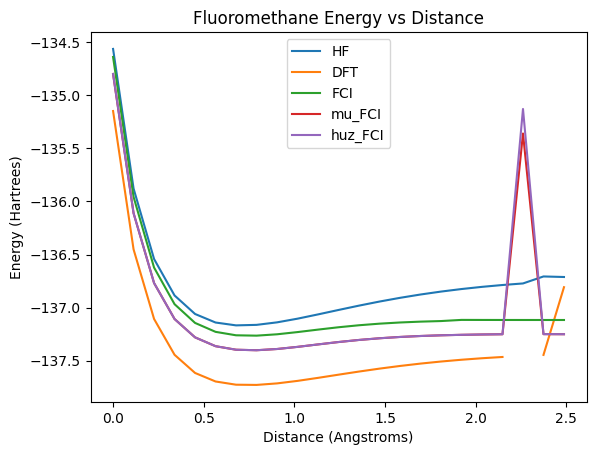

In [38]:
fluoromethane[['distances','HF', 'DFT','FCI', 'mu_FCI', 'huz_FCI']].plot(xlabel="Distance (Angstroms)", ylabel="Energy (Hartrees)", x="distances", title="Fluoromethane Energy vs Distance")

## Graph differences in energy from FCI

PBE is obviously well suited to creating dissociation curves.

<Axes: title={'center': 'Fluoromethane Energy Difference vs Distance'}, xlabel='distances'>

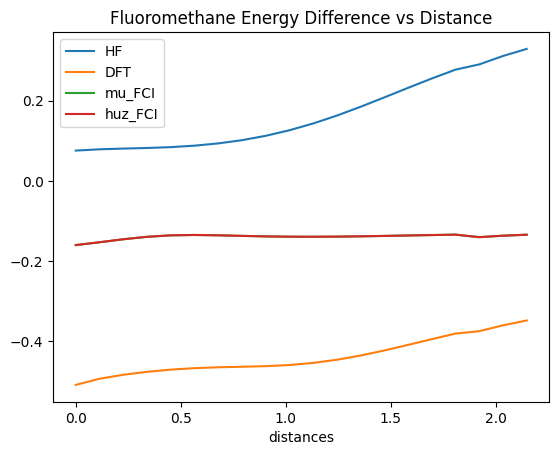

In [35]:
f_diffs = fluoromethane[['HF','DFT','mu_FCI', 'huz_FCI', *[f'mu_FCI_{i}' for i in range(1,4)], *[f'huz_FCI_{i}' for i in range(1,4)]]].subtract(fluoromethane["FCI"], axis=0)
f_diffs["distances"] = fluoromethane["distances"]
f_diffs[["distances","HF","DFT","mu_FCI","huz_FCI"]].loc[:19].plot(x="distances", title="Fluoromethane Energy Difference vs Distance")

With frozen core (no frozen virtuals yet)

<Axes: title={'center': 'Fluoromethane Energy Difference vs Distance'}, xlabel='distances'>

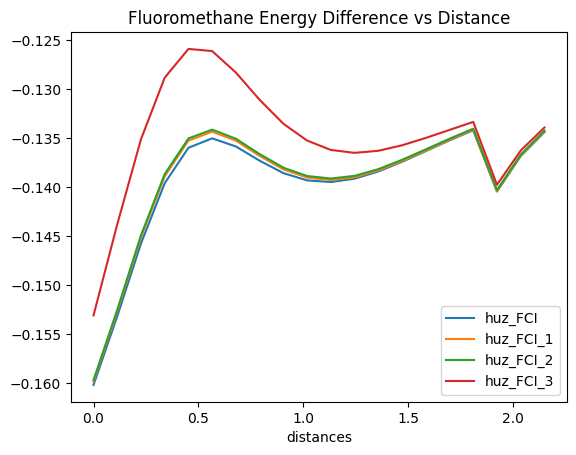

In [37]:
f_diffs[["distances", 'huz_FCI', *[f'huz_FCI_{i}' for i in range(1,4)]]].loc[:19].plot(x="distances", title="Fluoromethane Energy Difference vs Distance")

## PFOA

In [40]:
pfoa = pubchem_mol_geometry("Perfluorooctanoic acid")
pfoa_ordered = build_ordered_xyz_string(pfoa, active_atom_inds=[2,20])
save_ordered_xyz_file("pfoa", pfoa, active_atom_inds=[2,20])


'/dss/dsshome1/07/di46kaw/Nbed/docs/notebooks/projects/molecular_structures/pfoa.xyz'

In [41]:
pfoa

{0: ('F', (-1.0539, 1.9481, -0.2014)),
 1: ('F', (0.5434, 1.2581, -1.5025)),
 2: ('F', (1.2215, 1.6487, 1.0783)),
 3: ('F', (-0.3328, 0.2934, 1.7581)),
 4: ('F', (-1.8211, 0.1669, -2.1654)),
 5: ('F', (-0.4525, -1.3197, -1.355)),
 6: ('F', (2.0673, -0.7623, 1.9165)),
 7: ('F', (0.8055, -1.7942, 0.487)),
 8: ('F', (-2.9835, -1.7149, -0.6823)),
 9: ('F', (-1.6932, -1.3046, 1.0212)),
 10: ('F', (2.1054, -0.612, -1.6013)),
 11: ('F', (3.3419, -1.7554, -0.2365)),
 12: ('F', (-3.9677, 0.8422, -0.5956)),
 13: ('F', (-2.6826, 1.3007, 1.1093)),
 14: ('F', (-4.1728, -0.274, 1.2669)),
 15: ('O', (4.5699, 0.3287, 0.6742)),
 16: ('O', (3.3666, 1.6773, -0.7043)),
 17: ('C', (-0.2911, 0.8598, -0.5112)),
 18: ('C', (0.5314, 0.5262, 0.7274)),
 19: ('C', (-1.2138, -0.2391, -1.0209)),
 20: ('C', (1.5064, -0.6431, 0.6776)),
 21: ('C', (-2.285, -0.7254, -0.0556)),
 22: ('C', (2.6302, -0.5967, -0.3477)),
 23: ('C', (-3.2786, 0.3, 0.4302)),
 24: ('C', (3.5392, 0.5913, -0.1672)),
 25: ('H', (5.1534, 1.1082, 0

In [3]:
from pyscf.gto import Mole
from pathlib import Path
from pyscf.scf import RHF
from pyscf.dft import RKS

filepath = Path("molecular_structures/pfoa.xyz").absolute()
mol = Mole(atom=str(filepath), basis="sto-3g", verbose=4)
mol.build()

mf = RHF(mol)
mf.kernel()

ks = RKS(mol)
ks.conv_tol = 1e-6
ks.xc = "b3lyp"
ks.max_memory=400_000
ks.kernel()
print(mf.e_tot, ks.e_tot)

# from pyscf.cc import CCSD
# ccsd = CCSD(mf)
# ccsd.kernel()
# print(mf.e_tot, ccsd.e_tot)

System: uname_result(system='Linux', node='qlm', release='5.14.0-284.25.1.el9_2.x86_64', version='#1 SMP PREEMPT_DYNAMIC Thu Jul 20 09:11:28 EDT 2023', machine='x86_64')  Threads 10
Python 3.9.16 (main, May 29 2023, 00:00:00) 
[GCC 11.3.1 20221121 (Red Hat 11.3.1-4)]
numpy 1.23.5  scipy 1.10.1
Date: Thu Dec 14 18:33:19 2023
PySCF version 2.2.1
PySCF path  /usr/local/lib64/python3.9/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 26
[INPUT] num. electrons = 200
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 F      1.221500000000   1.648700000000   1.078300000000 AA    2.308300461156   3.115591461570   2.037691680119 Bohr   0.0
[INPUT]  2 C      1.506400000000  -0.643100000000   0.677600000000 AA    2.846683434045  -1.215282870

In [4]:
from pyscf.gto import Mole
from pathlib import Path
from pyscf.scf import RHF, UHF

filepath = Path("molecular_structures/pfoa_active.xyz").absolute()
mol = Mole(atom=str(filepath), basis="sto-3g", verbose=4, spin=1)
mol.build()

mf_active = RHF(mol)
mf_active.kernel()
print(mf_active.e_tot)

from pyscf.cc import CCSD
ccsd_active = CCSD(mf_active)
ccsd_active.kernel()
print(mf_active.e_tot, ccsd_active.e_tot)

System: uname_result(system='Linux', node='qlm', release='5.14.0-284.25.1.el9_2.x86_64', version='#1 SMP PREEMPT_DYNAMIC Thu Jul 20 09:11:28 EDT 2023', machine='x86_64')  Threads 10
Python 3.9.16 (main, May 29 2023, 00:00:00) 
[GCC 11.3.1 20221121 (Red Hat 11.3.1-4)]
numpy 1.23.5  scipy 1.10.1
Date: Thu Dec 14 18:33:56 2023
PySCF version 2.2.1
PySCF path  /usr/local/lib64/python3.9/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 15
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 1
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 F      1.221500000000   1.648700000000   1.078300000000 AA    2.308300461156   3.115591461570   2.037691680119 Bohr   0.0
[INPUT]  2 C      1.506400000000  -0.643100000000   0.677600000000 AA    2.846683434045  -1.21528287070

In [5]:
mf_active.mo_coeff.shape

(10, 10)

In [25]:
from nbed.driver import NbedDriver
args = {"geometry": pfoa_ordered, 
        "n_active_atoms": 2,
        "basis": "sto-3g",
        "xc_functional": "b3lyp",
        "projector": "both",
        "localization": "spade",
        "convergence": 1e-6,
        "max_ram_memory": 400_000,
        "run_ccsd_emb": True,
        }
driver = NbedDriver(**args)

Initialize <pyscf.gto.mole.Mole object at 0x1472438b3c10> in RKS object of <class 'pyscf.dft.rks.RKS'>
Initialize <pyscf.gto.mole.Mole object at 0x14a3df540af0> in RKS object of <class 'pyscf.dft.rks.RKS'>
2023-12-14 18:49:43,146: nbed.driver: WARNING: Outputting both mu and huzinaga embedding results as tuple.


In [33]:
driver.embedded_scf[0].mo_coeff.shape

(126, 1)

In [26]:
from pyscf import cc
energies = []
run_energy = cc.CCSD(driver.embedded_scf[0])
run_energy.run()
energies.append(run_energy.e_tot)

for i in range(driver.embedded_scf[0].mo_coeff.shape[-1]-1):
    print(i)
    driver.embedded_scf[0].mo_coeff = driver.embedded_scf[0].mo_coeff[:, :-1]
    driver.embedded_scf[0].mo_occ = driver.embedded_scf[0].mo_occ[:-1]
    ccsd = cc.CCSD(driver.embedded_scf[0])
    ccsd.run()
    energies.append(ccsd.e_tot)

E(CCSD) = 2982.661125294013  E_corr = -0.003731577229503544
0
E(CCSD) = 2982.661125313961  E_corr = -0.003731557282331833
1
E(CCSD) = 2982.661125331748  E_corr = -0.003731539495042412
2
E(CCSD) = 2982.661125411422  E_corr = -0.003731459821025562
3
E(CCSD) = 2982.661125486202  E_corr = -0.00373138504120143
4
E(CCSD) = 2982.661125559999  E_corr = -0.003731311243950723
5
E(CCSD) = 2982.661126180301  E_corr = -0.003730690942024746
6
E(CCSD) = 2982.661126367933  E_corr = -0.003730503310281151
7
E(CCSD) = 2982.661127120772  E_corr = -0.003729750471312955
8
E(CCSD) = 2982.661127692977  E_corr = -0.003729178266484441
9
E(CCSD) = 2982.661127977567  E_corr = -0.003728893676656555
10
E(CCSD) = 2982.661130898972  E_corr = -0.003725972270894575
11
E(CCSD) = 2982.661131925102  E_corr = -0.003724946140678297
12
E(CCSD) = 2982.661137939546  E_corr = -0.003718931696693596
13
E(CCSD) = 2982.661503890612  E_corr = -0.003352980631436309
14
E(CCSD) = 2982.662183935748  E_corr = -0.002672935495079736
15
E(C

In [47]:
(energies[1:] - energies[0])[::-1]

array([4.57030403e+01, 1.70863979e+01, 7.20938768e+00, 1.91815698e+00,
       3.73157723e-03, 3.70726717e-03, 3.68565051e-03, 3.54866563e-03,
       1.19737346e-03, 1.05864173e-03, 3.78596598e-04, 1.26455329e-05,
       6.63108904e-06, 5.60495891e-06, 2.68355325e-06, 2.39896326e-06,
       1.82675831e-06, 1.07391952e-06, 8.86287580e-07, 2.65985818e-07,
       1.92188509e-07, 1.17408490e-07, 3.77344804e-08, 1.99474925e-08])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
[4.57030403e+01 1.70863979e+01 7.20938768e+00 1.91815698e+00
 3.73157723e-03 3.70726717e-03 3.68565051e-03 3.54866563e-03
 1.19737346e-03 1.05864173e-03 3.78596598e-04 1.26455329e-05
 6.63108904e-06 5.60495891e-06 2.68355325e-06 2.39896326e-06
 1.82675831e-06 1.07391952e-06 8.86287580e-07 2.65985818e-07
 1.92188509e-07 1.17408490e-07 3.77344804e-08 1.99474925e-08]


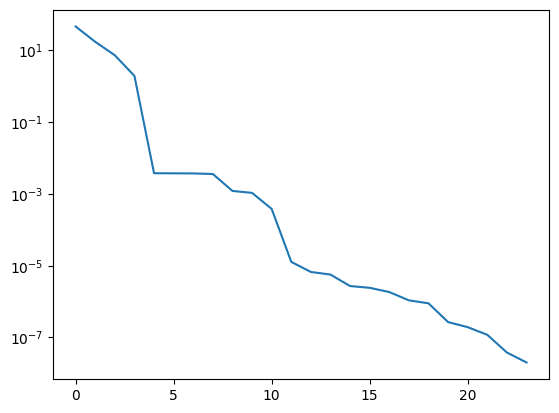

In [49]:
import matplotlib.pyplot as plt

x = [i for i in range(len(energies)-1)]

y = (energies[1:] - energies[0])[::-1]

print(x)
print(y)

plt.semilogy(x, y)

In [31]:
driver._mu["e_ccsd"]

-1924.6056827051057

In [11]:
print(len(driver.embedded_scf[0].mo_occ))
driver.embedded_scf[0].mo_occ

25


array([2., 2., 2., 2., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.])

In [13]:
from nbed.ham_builder import HamiltonianBuilder

hb = HamiltonianBuilder(driver.embedded_scf[0], constant_e_shift=driver.classical_energy[0])
hb.build(taper=True, core_indices=[0,1,2], active_indices=[i for i in range(3,25)])

Unable to poll TPU GCE metadata: HTTPConnectionPool(host='metadata.google.internal', port=80): Max retries exceeded with url: /computeMetadata/v1/instance/attributes/accelerator-type (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x14a3ec489730>: Failed to establish a new connection: [Errno -2] Name or service not known'))


2023-12-14 18:41:18,750	INFO worker.py:1642 -- Started a local Ray instance.


KeyboardInterrupt: 